# Authors

- David Robredo Manuel 
- Duarte Novas Álvarez 
- Rubén González Braña

## Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from os import listdir
from os.path import isfile, join

#### LOADING DATA

In [2]:
path = "./histories/"
history_dataframes = [
    (pd.read_csv(join(path, f), index_col=0), f) 
    for f in listdir(path) if isfile(join(path, f))
]


## Comparison

**NUMBER OF EPOCHS**

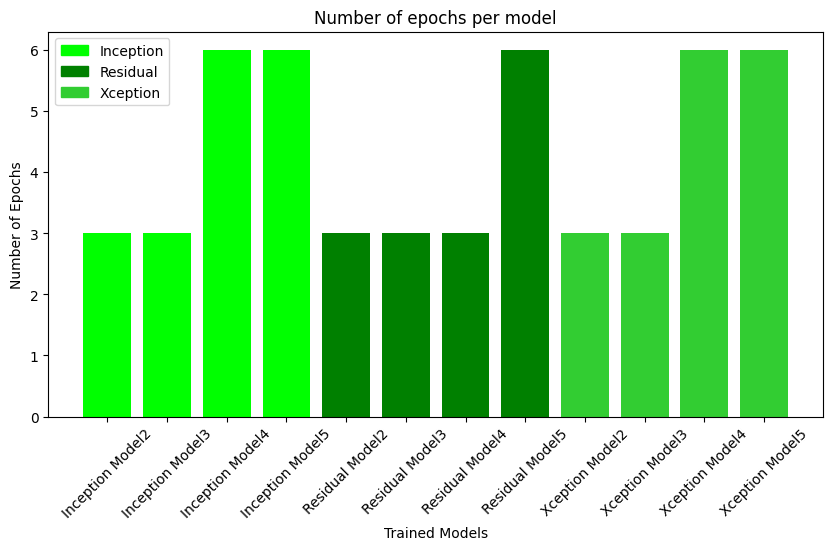

In [4]:
epochs = [len(df) for df, name in history_dataframes]
models = [f"{name.split(".")[0].split('_')[0]} {name.split(".")[0].split('_')[1]}" for _, name in history_dataframes]

colors = ['lime'] * 4 + ['green'] * 4 + ['limegreen'] * 4

plt.figure(figsize=(10, 5))
plt.bar(models, epochs, color=colors)
plt.xlabel("Trained Models")
plt.ylabel("Number of Epochs")
plt.xticks(rotation=45)
plt.title("Number of epochs per model")

legend_text = [
    mpatches.Patch(color='lime', label='Inception'),
    mpatches.Patch(color='green', label='Residual'),
    mpatches.Patch(color='limegreen', label='Xception')
]
plt.legend(handles=legend_text)

plt.show()

**Explanation**

The models have been trained with a different number of epochs mainly due to their training process. Models using the dataset without sift transform and canny edge detector converged more rapidly than the ones using those modified datasets. Therefore, the models using those were given more epochs to see if they could converge with more epochs.

**VALIDATION LOSS & ACCURACY**

ACCURACY

In [5]:
models = [
    (history_dataframes[:4], 'Inception'),
    (history_dataframes[4:8], 'Residual'),
    (history_dataframes[8:], 'Xception')
]

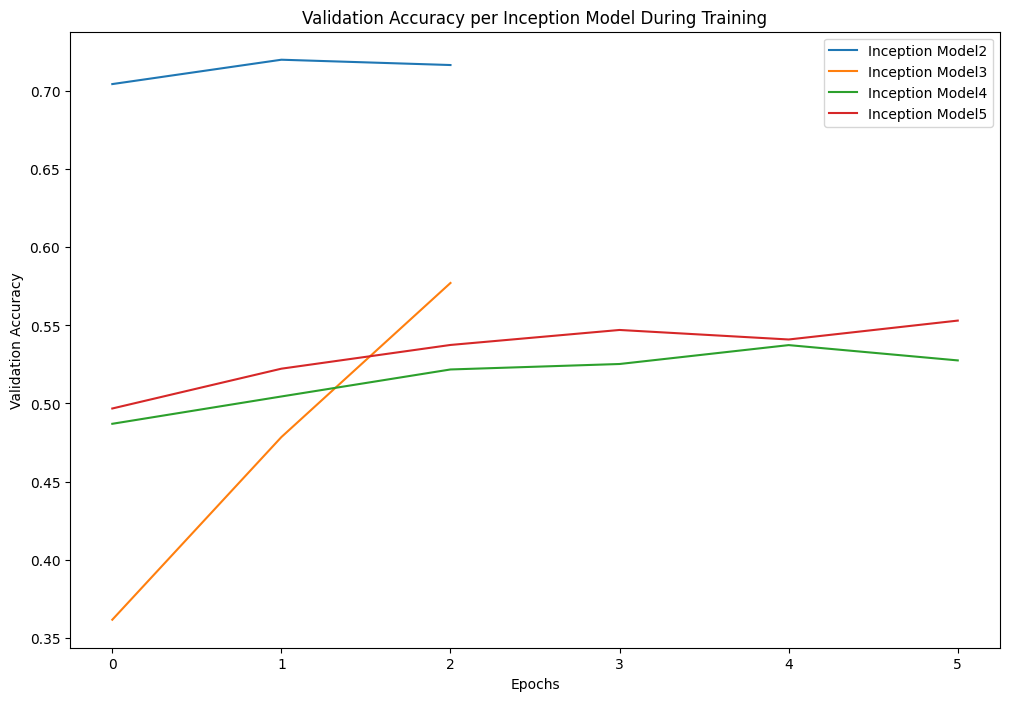

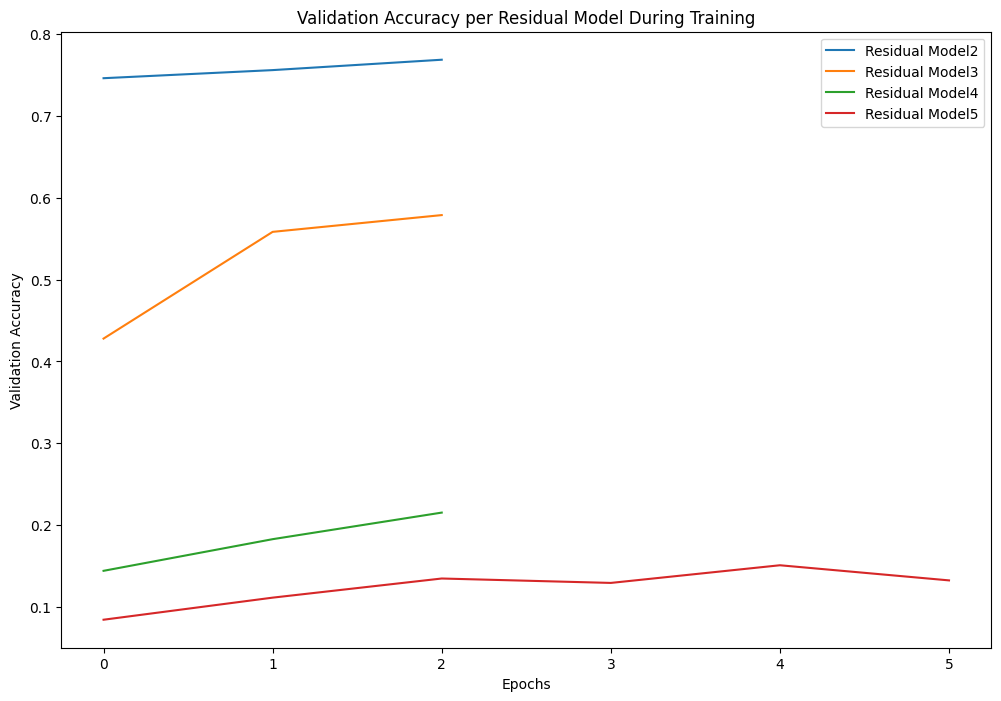

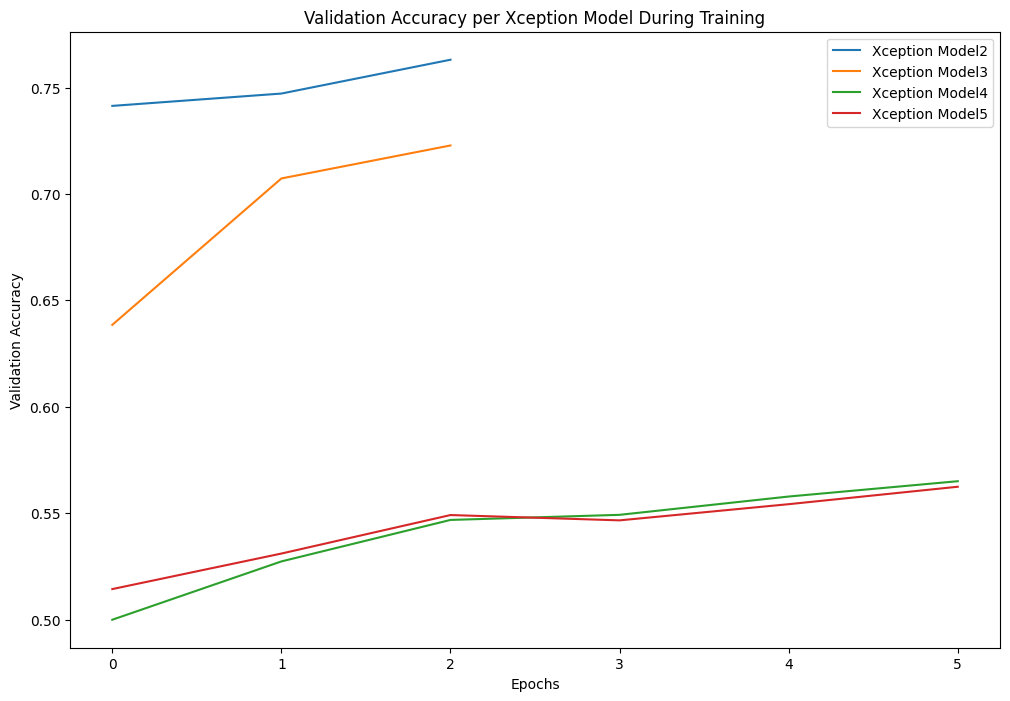

In [6]:
for model_data in models:
    plt.figure(figsize=(12, 8))
    
    for i, data in enumerate(model_data[0]):

        df = data[0]
        model_name = f"{data[1].split(".")[0].split("_")[0]} {data[1].split(".")[0].split("_")[1]}"

        plt.plot(df.index, df['val_accuracy'], label=model_name)

    plt.xlabel("Epochs")
    plt.ylabel("Validation Accuracy")
    plt.title(f"Validation Accuracy per {model_data[1]} Model During Training")
    plt.legend()
    plt.show()

**Explanation**

As it can be seen in these images, models using the normal dataset have better accuracy than the ones using the sift and canny datasets, even though the last ones are given the double epochs to train. This proves that only using fine tuning works better than using feature extraction in this case. Additionally, the results shown by the models that used the **imagenet** weights without training them in the process of training the network (the model2 for each type of model) are better than the ones were the **imagent** weights are train (models3).

LOSS

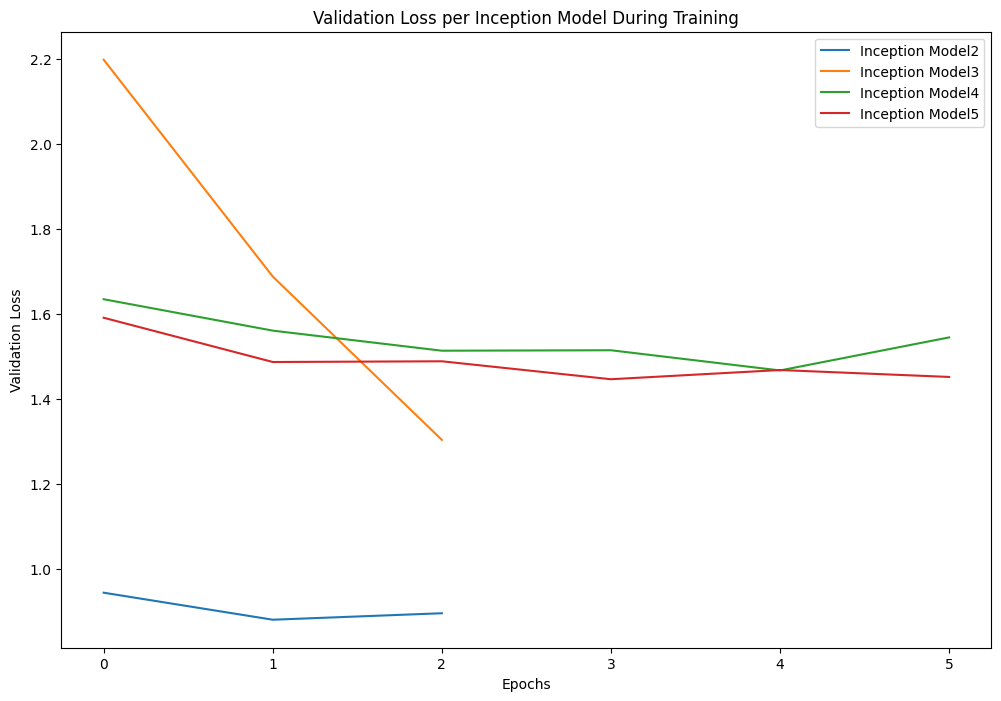

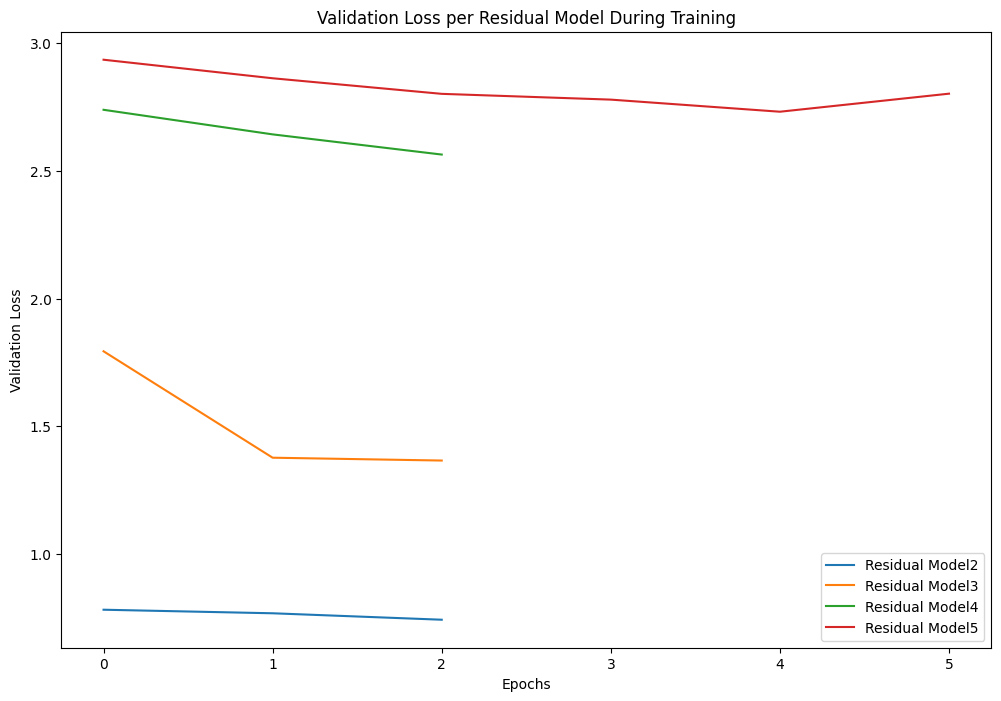

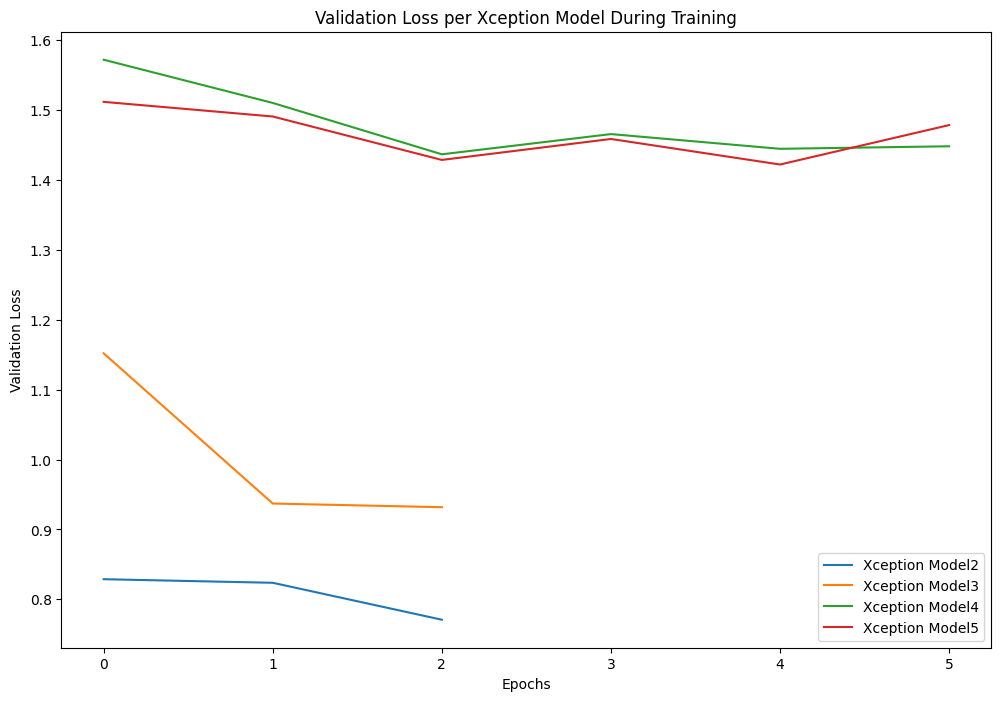

In [7]:

for model_data in models:
    plt.figure(figsize=(12, 8))

    for i, data in enumerate(model_data[0]):

        df = data[0]
        model_name = f"{data[1].split(".")[0].split("_")[0]} {data[1].split(".")[0].split("_")[1]}"

        plt.plot(df.index, df['val_loss'], label=model_name)

    plt.xlabel("Epochs")
    plt.ylabel("Validation Loss")
    plt.title(f"Validation Loss per {model_data[1]} Model During Training")
    plt.legend()
    plt.show()

**Explanation**

In terms of loss, results are very similar that in terms of accuracy, being valid everything said in previous explanation also for this part 


---

**EVALUATION RESULTS**

In [3]:
test_accuracies = {
    "Xception_1": 0.058,
    "Xception_2": 0.760,
    "Xception_3": 0.713,
    "Xception_4": 0.566,
    "Xception_5": 0.565,
    "Residual_1": 0.004,
    "Residual_2": 0.759,
    "Residual_3": 0.577,
    "Residual_4": 0.215,
    "Residual_5": 0.133,
    "Inception_1": 0.047,
    "Inception_2": 0.711,
    "Inception_3": 0.578,
    "Inception_4": 0.529,
    "Inception_5": 0.543
}

In [4]:
xception = {k: v for k, v in test_accuracies.items() if k.startswith("Xception")}
residual = {k: v for k, v in test_accuracies.items() if k.startswith("Residual")}
inception = {k: v for k, v in test_accuracies.items() if k.startswith("Inception")}

print("Xception Models:", xception)
print("Residual Models:", residual)
print("Inception Models:", inception)

Xception Models: {'Xception_1': 0.058, 'Xception_2': 0.76, 'Xception_3': 0.713, 'Xception_4': 0.566, 'Xception_5': 0.565}
Residual Models: {'Residual_1': 0.004, 'Residual_2': 0.759, 'Residual_3': 0.577, 'Residual_4': 0.215, 'Residual_5': 0.133}
Inception Models: {'Inception_1': 0.047, 'Inception_2': 0.711, 'Inception_3': 0.578, 'Inception_4': 0.529, 'Inception_5': 0.543}


In [5]:
model_labels = ['No training', 'Normal dataset - No weight modification', 'Normal dataset', 'Canny Dataset - No weight modification', 'Sift dataset - No weight modification']

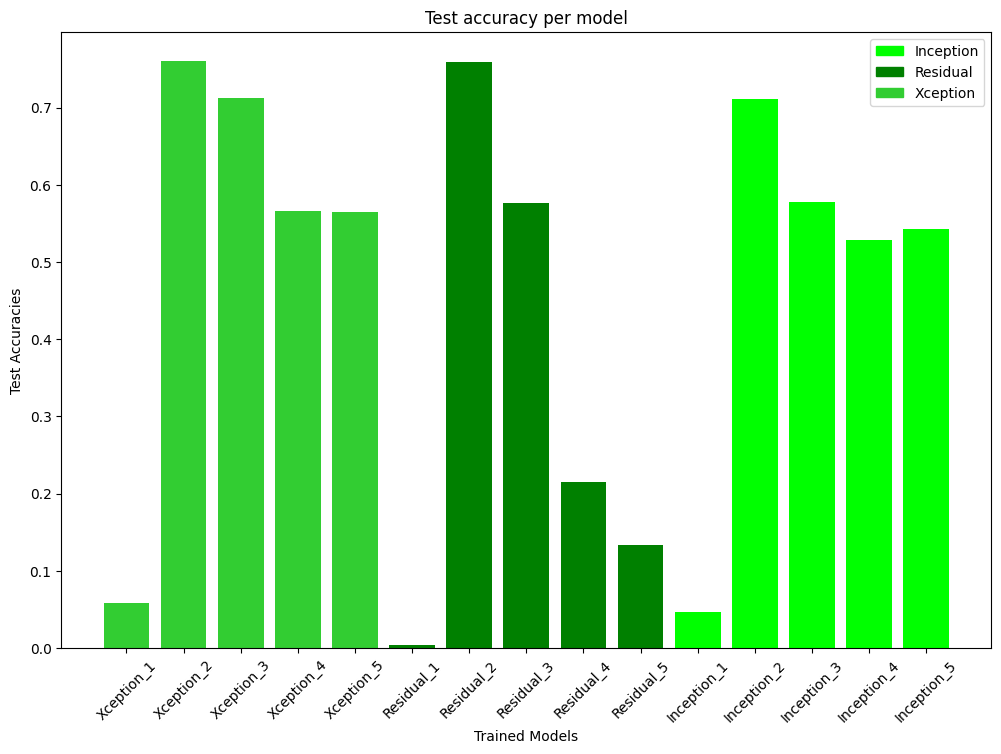

In [6]:
colors = ['limegreen'] * 5 + ['green'] * 5 + ['lime'] * 5

# Bar plot
plt.figure(figsize=(12, 8))
plt.bar(test_accuracies.keys(), test_accuracies.values(), color=colors)
plt.xlabel("Trained Models")
plt.ylabel("Test Accuracies")
plt.xticks(rotation=45)
plt.title("Test accuracy per model")

legend_text = [
    mpatches.Patch(color='lime', label='Inception'),
    mpatches.Patch(color='green', label='Residual'),
    mpatches.Patch(color='limegreen', label='Xception')
]
plt.legend(handles=legend_text)

plt.show()

**Explanation**

As it can be seen, in comparison, the Xception model is the most consistent independently of the process we apply to it in this work. Its model 2, where the network is trained but not the imaget weights and the normal dataset is used, has the best test accuracy among all models, with the models using the canny (model4) and sift (model5) dataset also obtaining great results. The Residual model obtains great results also when imagent weigths are not train and the normal dataset is used, but in the rest it obtains the worst results among all models. Finally, Inception models would be situated in the middle in terms of performance, having generally better results than Residual models, but being surpassed by Xception models.

From the information shown in this image, we can deduce that fine tuning is a better option than feature extraction, since it obtains better results in all instances than feature extraction. This is probably be caused by the way in which **imagenet** weights might be obtained, supporting more fine tuning than feature extraction.

The clear advantages of using fine tuning are its results, however, it showed sometimes to take longer to train in terms of time per epoch. On the other hand, feature extraction has as its main disadvantage its results that, even though in most of the cases are good, they are surpassed clearly by the ones from fine tuning. Also, the preprocessing needed to apply is a little more complex since it needs to extract the features before training the models, which increases the whole time for training.

**XCEPTION EVALUATION RESULTS**

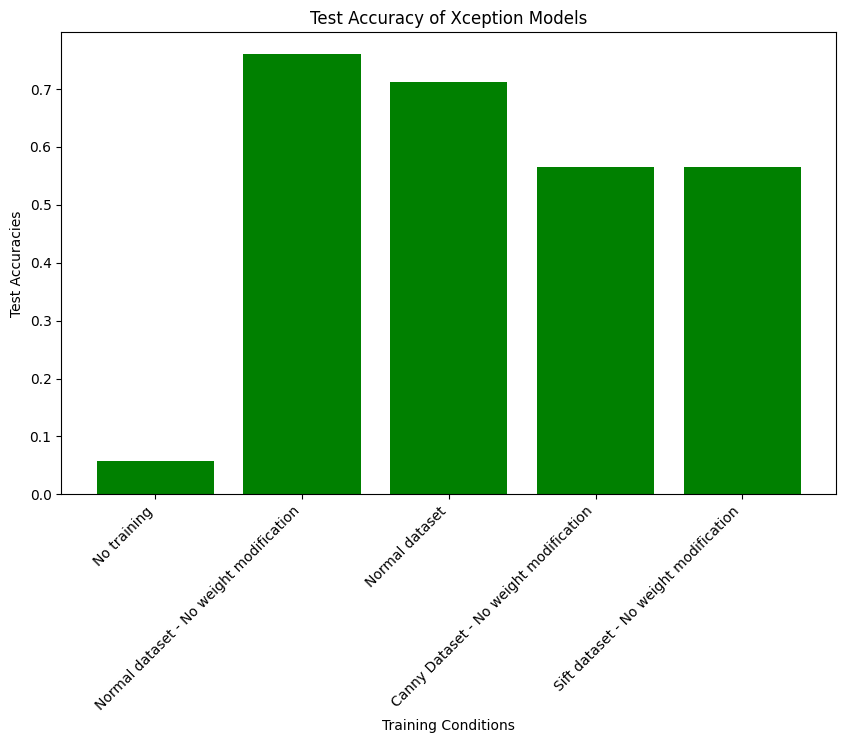

In [12]:
plt.figure(figsize=(10, 6))
plt.bar(model_labels, xception.values(), color='green')
plt.xlabel("Training Conditions")
plt.ylabel("Test Accuracies")
plt.xticks(rotation=45, ha='right')
plt.title("Test Accuracy of Xception Models")
plt.show()

In the dataset with no weight modification, the accuracy is close to 75%. This could indicate that the pretrained weights of model Xception are already quite robust at recognizing certain visual features of the CIFAR-100. According to the normal dataset, it presents a slightly lower accuracy, maybe because Xception with his initial weights was already at an optimal point for CIFAR-100, and by training him, instead of improving, it deteriorated those good weights.

On the other way, taking into account the feature extraction datasts (Canny Edge detection and SIFT transform) we can see that both have a similar accuracy of ~55%, but maybe for different reasons. Canny keeps the global shapes in the images and SIFT saves only local key points. Xception model seems to adapt properly and equally to both transformations, depending more on general structures than on concrete details.

**RESIDUAL EVALUATION RESULTS**

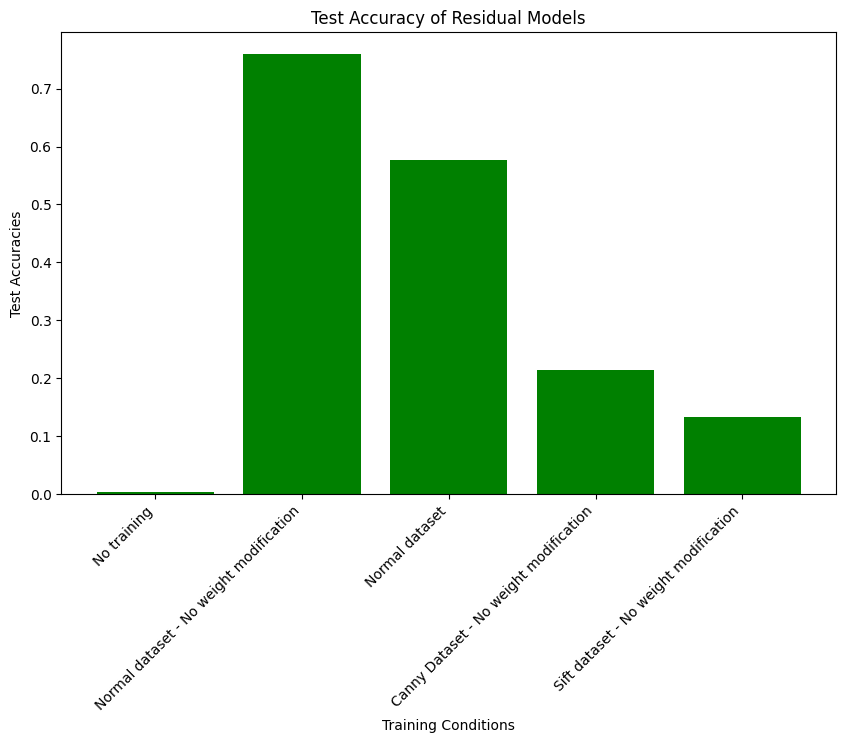

In [13]:
plt.figure(figsize=(10, 6))
plt.bar(model_labels, residual.values(), color='green')
plt.xlabel("Training Conditions")
plt.ylabel("Test Accuracies")
plt.xticks(rotation=45, ha='right')
plt.title("Test Accuracy of Residual Models")
plt.show()


In case of the Residual models, again, the dataset with no weight modification shows us a better accuracy than the normal dataset (again around 75%), which could be explained in the same way as above. For the Canny and SIFT datasets, the former (~20%) presents a slightly greater accuracy than the latter (~15%). However, both accuracies are low, so we can conclude that Residual model is designed to extract more complex features which go beyond edges or key points.

**INCEPTION EVALUATION RESULTS**

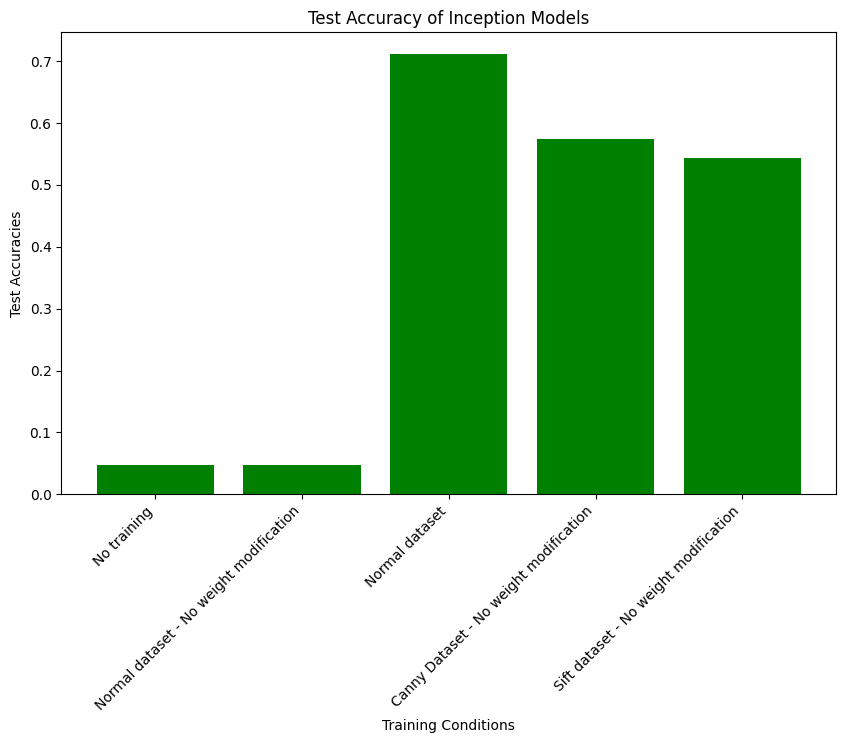

In [14]:
plt.figure(figsize=(10, 6))
plt.bar(model_labels, inception.values(), color='green')
plt.xlabel("Training Conditions")
plt.ylabel("Test Accuracies")
plt.xticks(rotation=45, ha='right')
plt.title("Test Accuracy of Inception Models")
plt.show()


Following the same pattern as above, the model with no weight modification is the best one. Regarding feature extraction datasets, the general accuracies are higher than in the previous model, that could reflect a correct adaptation to general structures. However, the better performance in the Canny dataset may indicate that contour information is more useful to Inception than the isolated key points extracted by SIFT (~60% accuracy in the first case vs. ~55% accuracy in the second one).

**GENERAL CONCLUSIONS**

Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas Aquí hay que explicar cosas 


**ADVANTAGES AND DISVANTAGES**

TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA TABLA 